In [298]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# Loading the Dataset

The AirPassengers dataset contains the monthly number of international airline passengers from 1949 to 1960.

Since observations are recorded sequentially over time, this is a time series forecasting problem rather than a traditional regression problem.

Our objective is to build a model capable of forecasting future passenger demand while accounting for long-term trends and recurring seasonal patterns.

In [299]:
df = pd.read_csv(r"C:\Users\sahaa\OneDrive\Documents\Time Series\AirPassengers.csv")
y = np.log(df['Passengers'])


## Train-Test Split

Unlike standard machine learning problems, observations in time series are ordered chronologically.

Randomly shuffling observations would leak future information into the training data and produce unrealistically optimistic performance.

Instead, we reserve the final 24 months as the test set and train the model using only historical observations.

The test set acts as unseen future data, allowing us to evaluate the forecasting ability of the model.

In [300]:
train = df.iloc[:-24]
test = df.iloc[-24:]

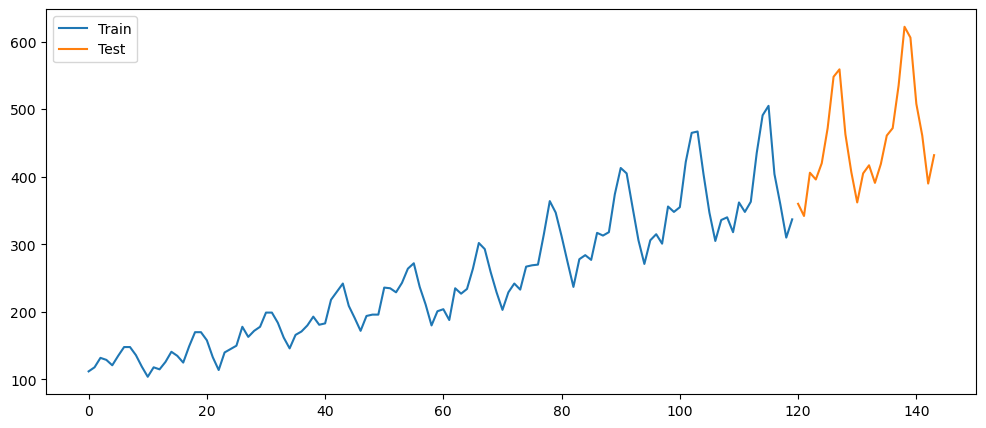

In [301]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test")

plt.legend()
plt.show()

## Log Transformation

The variance of the AirPassengers series increases over time.

Many time series models, including SARIMA, assume approximately constant variance.

Applying the natural logarithm stabilizes the variance, making the series more suitable for modelling while preserving the underlying trend and seasonal structure.

In [302]:
y_train = np.log(train["Passengers"])
y_test = np.log(test["Passengers"])

## Stationarity

SARIMA assumes that the underlying series is stationary.

A stationary time series has statistical properties such as mean, variance and autocorrelation that remain approximately constant over time.

The original AirPassengers data exhibits

- an increasing trend
- increasing variance
- strong yearly seasonality

Therefore the series is not stationary.

To determine the required transformations, the Augmented Dickey-Fuller (ADF) test is performed after progressively applying

1. Log transformation
2. First differencing
3. Seasonal differencing
4. Both first and seasonal differencing

The first transformation producing a statistically significant ADF test determines the required differencing orders (d and D).

In [303]:
series = {
    "log": y_train,
    "diff1": y_train.diff().dropna(),
    "diff12": y_train.diff(12).dropna(),
    "diff1_diff12": y_train.diff().diff(12).dropna()
}

for name, s in series.items():

    result = adfuller(s)

    print(name)
    print("ADF:", result[0])
    print("p:", result[1])
    print()

log
ADF: -1.924557326486782
p: 0.32059820532166683

diff1
ADF: -2.343170079688454
p: 0.15842238699553668

diff12
ADF: -1.7514338162917253
p: 0.4048258144231876

diff1_diff12
ADF: -4.004616296917245
p: 0.0013865309340907379



The ADF results indicate that only after applying both first-order and seasonal differencing does the series become stationary (p < 0.05).

Therefore

- d = 1
- D = 1
- Seasonal period = 12

## ACF and PACF

Once stationarity has been achieved, the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) are examined.

Historically, these plots were used to estimate appropriate values for

- p
- q
- P
- Q

However, interpreting ACF and PACF becomes difficult for seasonal models.

Instead of selecting a single model solely from visual inspection, these plots are used only to determine a reasonable search space for the subsequent grid search.

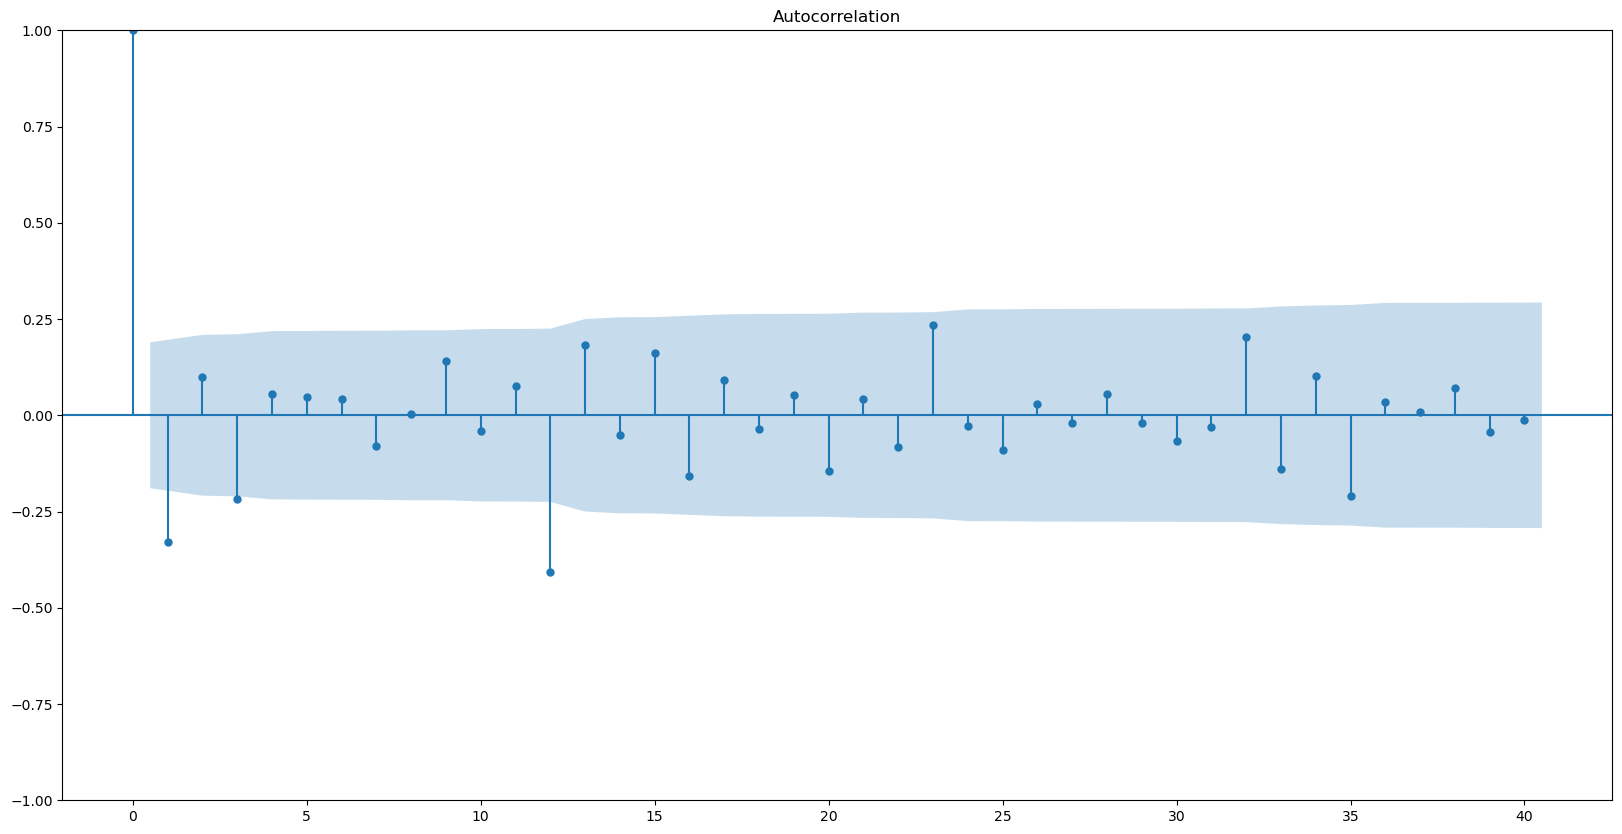

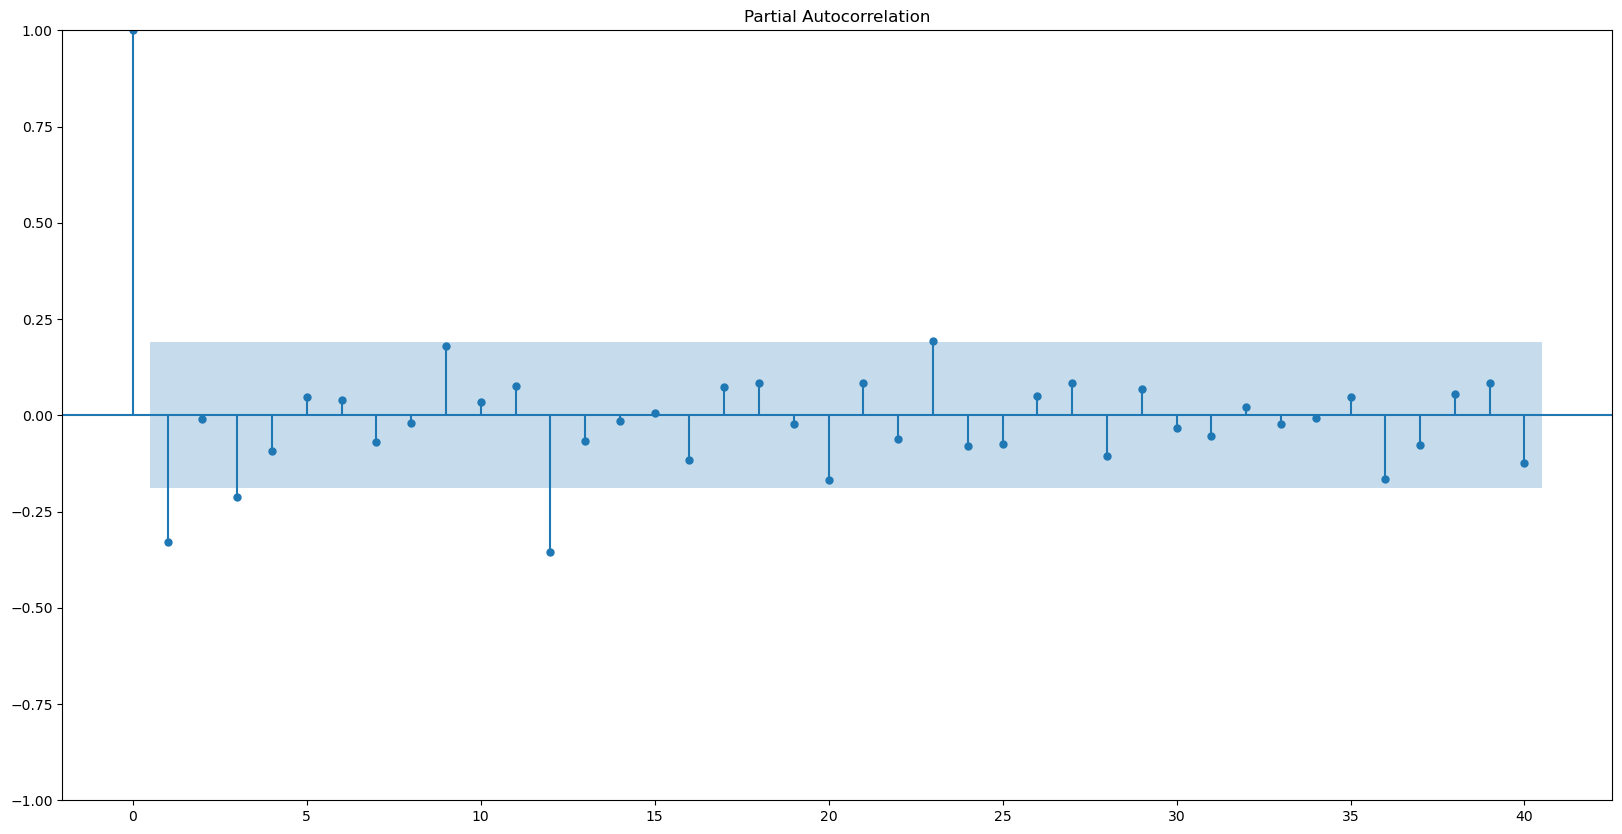

In [305]:
stationary = y_train.diff().diff(12).dropna()

plot_acf(stationary,lags=40)
plt.show()

plot_pacf(stationary,lags=40)
plt.show()


## Grid Search

Rather than manually selecting SARIMA orders, a grid search is performed across multiple combinations of

(p, q, P, Q).

Each candidate model is estimated using the training data.

Models that fail to converge are discarded.

The remaining models are ranked using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC), which balance model fit against complexity.

Only the best-performing candidate models are retained for further evaluation.

In [306]:
results = []

for p in range(3):
    for q in range(3):
        for P in range(3):
            for Q in range(3):

                try:

                    model = SARIMAX(
                        y_train,
                        order=(p,1,q),
                        seasonal_order=(P,1,Q,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )

                    fit = model.fit(disp=False)

                    if not fit.mle_retvals["converged"]:
                        continue

                    results.append({

                        "p":p,
                        "q":q,
                        "P":P,
                        "Q":Q,
                        "AIC":fit.aic,
                        "BIC":fit.bic

                    })

                except:

                    continue

results = pd.DataFrame(results)

results = results.sort_values("AIC")

results.head(10)


,p,q,P,Q,AIC,BIC
24,1,0,0,0,-359.977320,-354.650442
30,1,1,0,0,-354.635215,-346.673334
41,2,0,0,0,-353.654524,-345.692643
50,2,2,0,0,-350.704326,-337.482372
15,0,2,0,0,-350.189612,-342.256440
0,0,0,0,0,-349.816165,-347.152726
36,1,2,0,0,-349.002356,-338.424793
25,1,0,0,1,-344.392615,-336.762731
10,0,1,1,0,-343.451896,-335.790265
42,2,0,0,1,-342.369977,-332.196798


In [ ]:
results = []

for p in range(3):
    for q in range(3):
        for P in range(3):
            for Q in range(3):

                try:

                    model = SARIMAX(
                        y_train,
                        order=(p,1,q),
                        seasonal_order=(P,1,Q,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )

                    fit = model.fit(disp=False)

                    if not fit.mle_retvals["converged"]:
                        continue

                    results.append({

                        "p":p,
                        "q":q,
                        "P":P,
                        "Q":Q,
                        "AIC":fit.aic,
                        "BIC":fit.bic

                    })

                except:

                    continue

results = pd.DataFrame(results)

results = results.sort_values("AIC")

results.head(10)


,p,q,P,Q,AIC,BIC
24,1,0,0,0,-359.977320,-354.650442
30,1,1,0,0,-354.635215,-346.673334
41,2,0,0,0,-353.654524,-345.692643
50,2,2,0,0,-350.704326,-337.482372
15,0,2,0,0,-350.189612,-342.256440
0,0,0,0,0,-349.816165,-347.152726
36,1,2,0,0,-349.002356,-338.424793
25,1,0,0,1,-344.392615,-336.762731
10,0,1,1,0,-343.451896,-335.790265
42,2,0,0,1,-342.369977,-332.196798


In [316]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

comparison = []

# Top 5 models from the AIC search
top5 = results.head(5)

for _, row in top5.iterrows():

    p = int(row["p"])
    q = int(row["q"])
    P = int(row["P"])
    Q = int(row["Q"])

    model = SARIMAX(
        y_train,
        order=(p,1,q),
        seasonal_order=(P,1,Q,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    # Forecast the test period
    forecast = fit.get_forecast(steps=len(test))

    # Back-transform to original scale
    forecast_mean = np.exp(forecast.predicted_mean)

    actual = test["Passengers"]

    mae = mean_absolute_error(actual, forecast_mean)
    rmse = np.sqrt(mean_squared_error(actual, forecast_mean))
    mape = mean_absolute_percentage_error(actual, forecast_mean)

    comparison.append({

        "Model": f"SARIMA({p},1,{q})({P},1,{Q},12)",

        "AIC": fit.aic,

        "BIC": fit.bic,

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape

    })

comparison = pd.DataFrame(comparison)

comparison = comparison.sort_values("MAPE")

comparison

,Model,AIC,BIC,MAE,RMSE,MAPE
3,"SARIMA(2,1,2)(0,1,0,12)",-350.704326,-337.482372,38.612910,41.848287,0.085406
1,"SARIMA(1,1,1)(0,1,0,12)",-354.635215,-346.673334,64.359277,69.770351,0.140246
4,"SARIMA(0,1,2)(0,1,0,12)",-350.189612,-342.256440,65.072041,70.528305,0.141784
2,"SARIMA(2,1,0)(0,1,0,12)",-353.654524,-345.692643,67.468195,73.048736,0.146988
0,"SARIMA(1,1,0)(0,1,0,12)",-359.977320,-354.650442,67.632069,73.219886,0.147346


We choose the model with lowest MAPE, not the lowest AIC. Note that, in the unseen data, the one with lowest AIC is the worst of the five models.


The model SARIMA(1,1,0) fit the training data very well. but performed poorly on future observations. Another model SARIMA(2,1,2) had a worse AIC, yet predicted the future more accurately.

Now, we plot the winner.


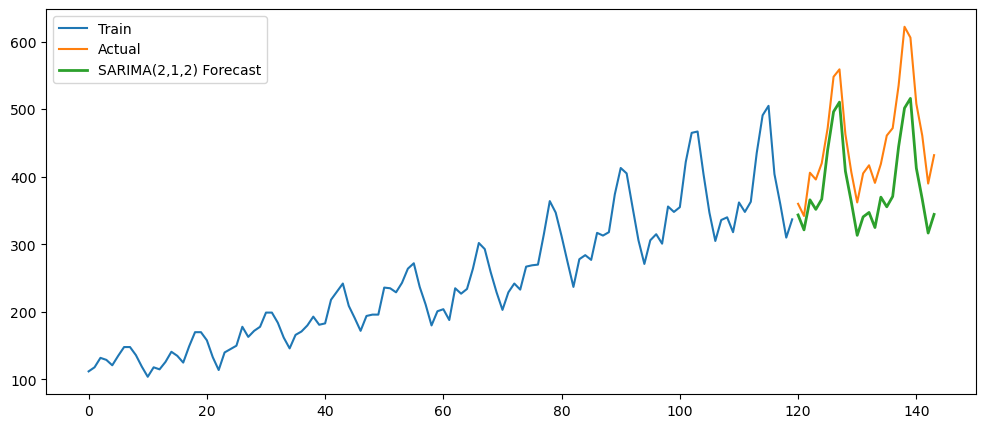

In [318]:
forecast = fit.get_forecast(steps=len(test))

forecast_mean = np.exp(forecast.predicted_mean)

plt.figure(figsize=(12,5))

plt.plot(train.index,
         train["Passengers"],
         label="Train")

plt.plot(test.index,
         test["Passengers"],
         label="Actual")

plt.plot(forecast_mean.index,
         forecast_mean,
         label="SARIMA(2,1,2) Forecast",
         linewidth=2)

plt.legend()

plt.show()

In [319]:
y = np.log(df["Passengers"])

final_model = SARIMAX(
    y,
    order=(2,1,2),
    seasonal_order=(0,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit()

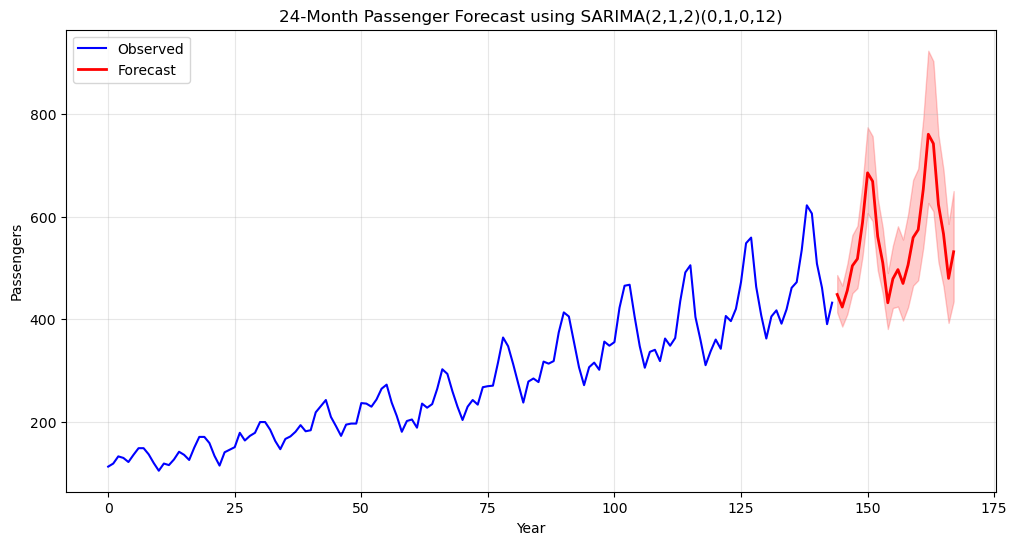

In [320]:
# Refit on all available data
y = np.log(df["Passengers"])

final_model = SARIMAX(
    y,
    order=(2,1,2),
    seasonal_order=(0,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit()

# Forecast next 24 months
forecast = final_fit.get_forecast(steps=24)

forecast_mean = np.exp(forecast.predicted_mean)
forecast_ci = np.exp(forecast.conf_int())

# Plot
plt.figure(figsize=(12,6))

# Historical observations
plt.plot(
    df.index,
    df["Passengers"],
    label="Observed",
    color="blue"
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    color="red",
    linewidth=2
)

# 95% confidence interval
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="red",
    alpha=0.2
)

plt.title("24-Month Passenger Forecast using SARIMA(2,1,2)(0,1,0,12)")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

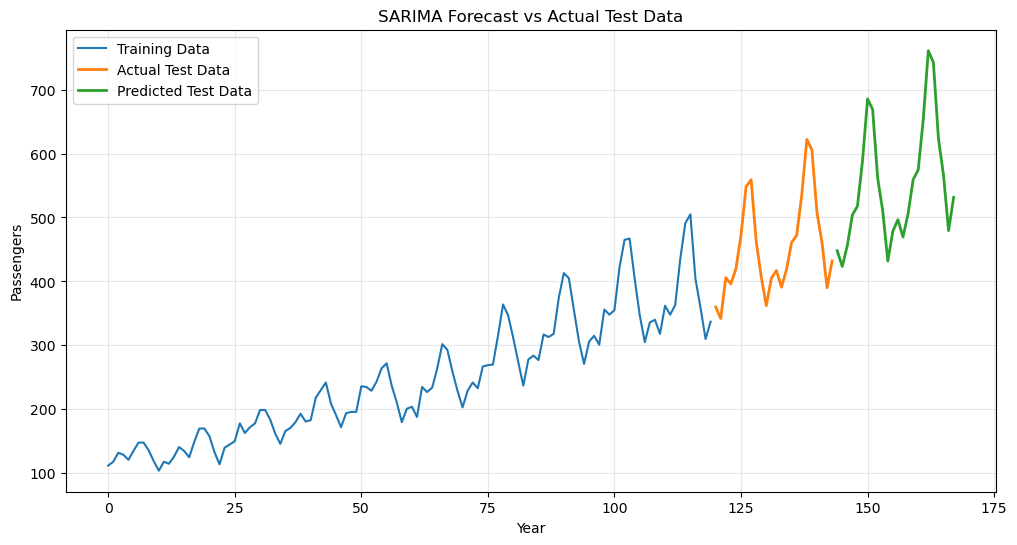

In [321]:
# Forecast on the test set
forecast = final_fit.get_forecast(steps=len(test))

forecast_mean = np.exp(forecast.predicted_mean)

plt.figure(figsize=(12,6))

plt.plot(train.index,
         train["Passengers"],
         label="Training Data")

plt.plot(test.index,
         test["Passengers"],
         label="Actual Test Data",
         linewidth=2)

plt.plot(forecast_mean.index,
         forecast_mean,
         label="Predicted Test Data",
         linewidth=2)

plt.title("SARIMA Forecast vs Actual Test Data")
plt.xlabel("Year")
plt.ylabel("Passengers")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Let us run diagnostics on the final model.


In [323]:
print(final_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          Passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 2)x(0, 1, [], 12)   Log Likelihood                 224.706
Date:                             Sun, 28 Jun 2026   AIC                           -439.411
Time:                                     01:46:34   BIC                           -425.151
Sample:                                          0   HQIC                          -433.617
                                             - 144                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1479      0.301      0.491      0.624      -0.443       0.739
ar.L2          0.5031      



The model summary provides estimates of the AR and MA coefficients together with their statistical significance.

Some coefficients are not individually significant at the 5% level.

While this may indicate a more complex model than necessary from an inferential perspective, forecasting performance is ultimately assessed using unseen test data.

Therefore, coefficient significance is considered alongside predictive accuracy rather than being the sole criterion for model selection.

## Residual Diagnostics

A well-specified SARIMA model should leave behind residuals that behave like white noise.

Residual diagnostics verify that the model has successfully captured the temporal dependence present in the data.

The following checks are performed:

- Residual plot
- Residual ACF
- Ljung–Box test
- Jarque–Bera normality test


### Ljung–Box Test

The Ljung–Box test evaluates whether significant autocorrelation remains in the residuals.

Null hypothesis:

Residuals are independently distributed.

If the p-value exceeds 0.05, we fail to reject the null hypothesis, suggesting that the model has adequately captured the serial dependence.

If significant autocorrelation remains, the model may require additional AR or MA terms.

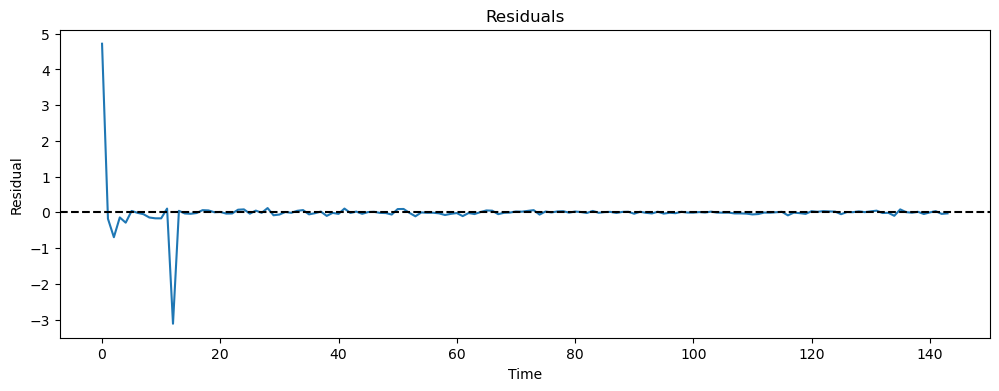

In [324]:
plt.figure(figsize=(12,4))

plt.plot(final_fit.resid)

plt.axhline(0,color='black',linestyle='--')

plt.title("Residuals")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.show()

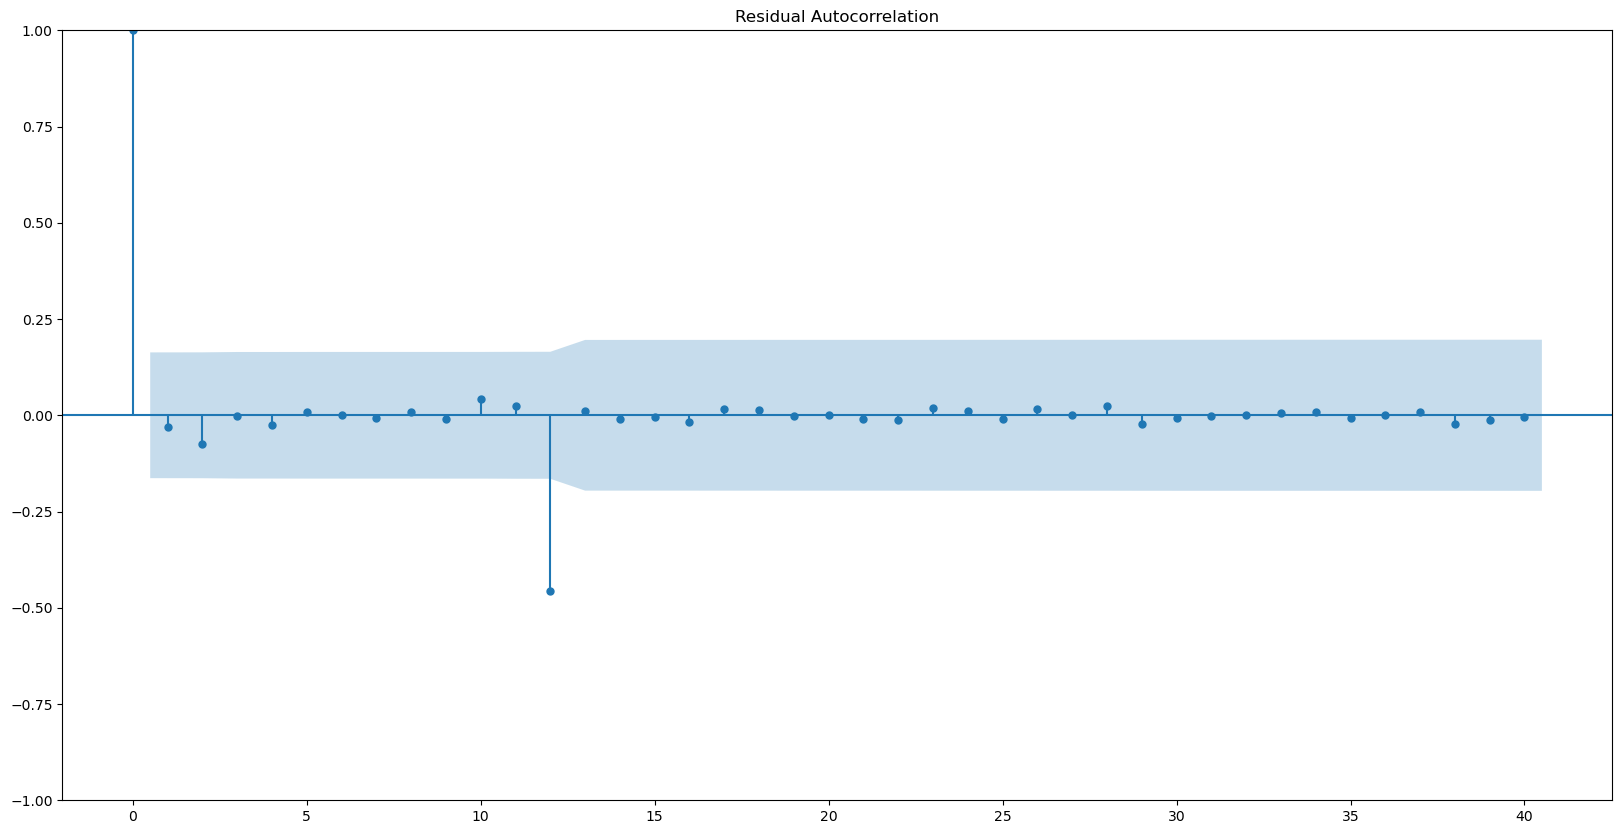

In [325]:
plot_acf(final_fit.resid, lags=40)

plt.title("Residual Autocorrelation")

plt.show()



The residual autocorrelation function (ACF) was examined to determine whether any serial dependence remains after fitting the model.

Most autocorrelations lie within the confidence bounds, although a noticeable seasonal spike remains around lag 12.

This indicates that while the model captures the majority of the temporal structure, some seasonal dependence may still remain.

In [326]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    final_fit.resid,
    lags=[12,24],
    return_df=True
)

print(lb)

      lb_stat  lb_pvalue
12  34.636656   0.000535
24  34.924618   0.069526




The Ljung-Box test evaluates whether residual autocorrelation remains after fitting the model.

The null hypothesis states that the residuals are independently distributed.

The test indicates significant autocorrelation at lag 12 but not at lag 24.

This suggests that a small amount of seasonal dependence remains in the residuals.

However, when compared against competing models, the selected SARIMA specification achieved the lowest forecasting error on the unseen test set.

Consequently, the model was retained because the primary objective of this project is accurate forecasting rather than perfect residual diagnostics.

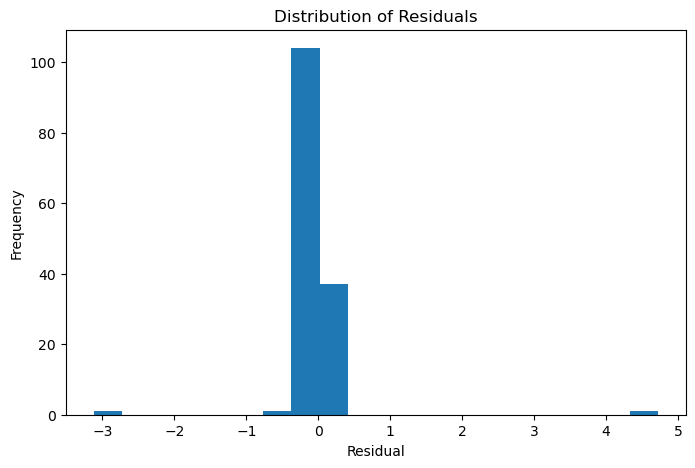

In [327]:
plt.figure(figsize=(8,5))

plt.hist(final_fit.resid,bins=20)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

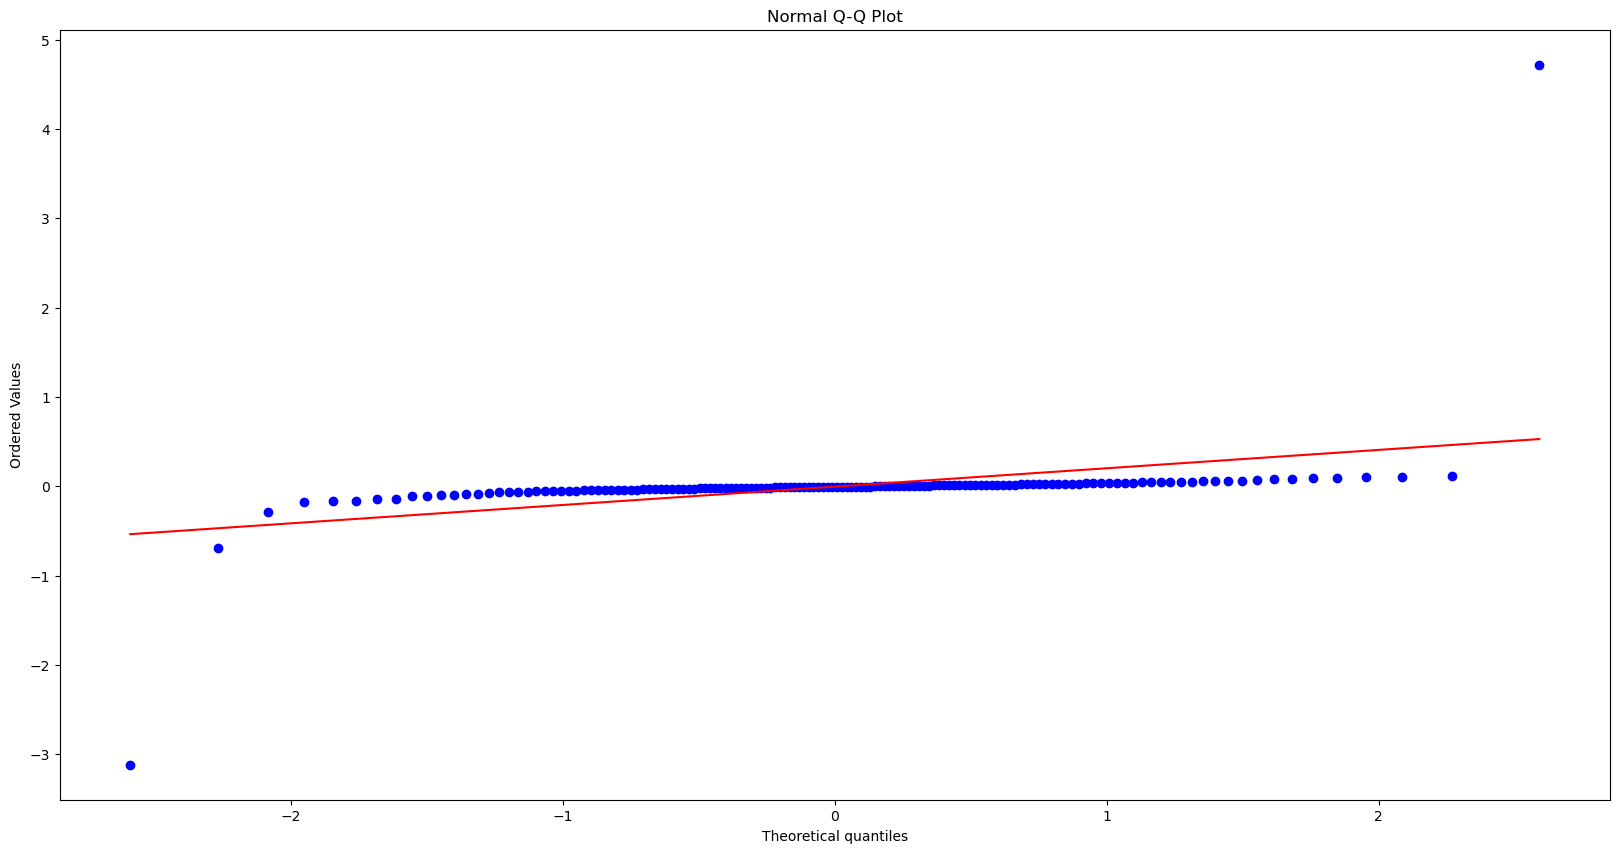

In [328]:
from scipy import stats

stats.probplot(final_fit.resid, dist="norm", plot=plt)

plt.title("Normal Q-Q Plot")

plt.show()



The residual histogram is approximately symmetric and centered around zero.

The Q-Q plot indicates that the residuals follow the normal distribution reasonably well, with only minor departures in the tails.

Since SARIMA forecasting is generally robust to mild deviations from normality, these results do not raise major concerns regarding model adequacy.

In [329]:
print("Residual Mean :", final_fit.resid.mean())

print("Residual Std  :", final_fit.resid.std())

Residual Mean : -0.003627842625007908
Residual Std  : 0.47978029030862107




This project demonstrated a complete SARIMA forecasting workflow, including stationarity testing, seasonal differencing, hyperparameter tuning, model diagnostics, and out-of-sample forecast evaluation.


To conclude,

Residual diagnostics indicate that the fitted model produces approximately unbiased and normally distributed residuals.

The Ljung–Box test suggests that some seasonal autocorrelation remains at lag 12, indicating that the model does not fully capture all seasonal dependence in the data.

In addition, not all AR and MA coefficients are statistically significant.

However, when evaluated on the unseen test set, this specification achieved the lowest forecasting error (MAPE = 8.54%) among the candidate models.

Therefore, the model was retained as the final forecasting model based on its superior predictive performance rather than solely on in-sample statistical diagnostics.